# AvianTech — 3-Model Comparison Notebook
### YOLOv5s vs YOLOv11s vs YOLO26s
**37 Philippine Bird Species | Visual + Audio (BirdNET) Fusion**


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# ── Paths ──────────────────────────────────────────────────────────────────
v5_csv   = r"C:\Users\Christian\AvianTech\models\yolov5\aviantech_birds_v2\results.csv"
v11_csv  = r"C:\Users\Christian\AvianTech\models\yolov11\aviantech_v11_phase2\results.csv"
v26_csv  = r"C:\Users\Christian\AvianTech\models\yolo26\aviantech_v26_phase1\results.csv"

v11_xlsx = r"C:\Users\Christian\AvianTech\results_charts_v11\aviantech_full_results.xlsx"
v26_xlsx = r"C:\Users\Christian\AvianTech\results_charts_v26\aviantech_v26_full_results.xlsx"

save_dir = r"C:\Users\Christian\AvianTech\results_charts_final"
os.makedirs(save_dir, exist_ok=True)

# ── Load CSVs ───────────────────────────────────────────────────────────────
df5  = pd.read_csv(v5_csv);  df5.columns  = df5.columns.str.strip()
df11 = pd.read_csv(v11_csv); df11.columns = df11.columns.str.strip()
df26 = pd.read_csv(v26_csv); df26.columns = df26.columns.str.strip()

# ── Best epochs ─────────────────────────────────────────────────────────────
best5  = df5.loc[df5["metrics/mAP_0.5"].idxmax()]
best11 = df11.loc[df11["metrics/mAP50(B)"].idxmax()]
best26 = df26.loc[df26["metrics/mAP50(B)"].idxmax()]

# ── Test set results (from val runs) ────────────────────────────────────────
# These are the actual test set numbers from each model's val run
test_results = {
    "YOLOv5s":  {"mAP50": 0.753,  "mAP5095": 0.619,  "precision": 0.802,  "recall": 0.710},
    "YOLOv11s": {"mAP50": 0.855,  "mAP5095": 0.746,  "precision": 0.906,  "recall": 0.776},
    "YOLO26s":  {"mAP50": 0.787,  "mAP5095": 0.703,  "precision": 0.805,  "recall": 0.721},
}

# ── Style ───────────────────────────────────────────────────────────────────
BG, CARD = "#0f1117", "#1a1d27"
GRN, ACC, YLW, PRP, RED = "#00ff88", "#00d4ff", "#ffa502", "#a29bfe", "#ff4757"
ORG, CYN = "#ff6b35", "#00d4ff"
WHT, GRY = "#ffffff", "#8892a4"

# Model colors
C5, C11, C26 = "#ff4757", "#00d4ff", "#00ff88"

def save(fig, name):
    path = os.path.join(save_dir, name)
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show(); plt.close(fig)
    print(f"✅ Saved → {path}")

print("✅ All data loaded successfully!")
print(f"   YOLOv5s  — best epoch: {int(best5['epoch'])}")
print(f"   YOLOv11s — best epoch: {int(best11['epoch'])}")
print(f"   YOLO26s  — best epoch: {int(best26['epoch'])}")


✅ All data loaded successfully!
   YOLOv5s  — best epoch: 90
   YOLOv11s — best epoch: 88
   YOLO26s  — best epoch: 45


In [2]:
# ════════════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ════════════════════════════════════════════════════════════════════════════
print("=" * 72)
print(f"{'Metric':<22} {'YOLOv5s':>14} {'YOLOv11s':>14} {'YOLO26s':>14}")
print("=" * 72)

metrics = ["mAP50", "mAP5095", "precision", "recall"]
labels  = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall"]

for m, l in zip(metrics, labels):
    v5  = test_results["YOLOv5s"][m]
    v11 = test_results["YOLOv11s"][m]
    v26 = test_results["YOLO26s"][m]
    best_val = max(v5, v11, v26)
    def fmt(v): return f"{v*100:.2f}% {'⭐' if v == best_val else '  '}"
    print(f"  {l:<20} {fmt(v5):>14} {fmt(v11):>14} {fmt(v26):>14}")

print("=" * 72)
print(f"  {'Parameters':<20} {'7.1M':>14} {'9.4M':>14} {'9.5M':>14}")
print(f"  {'Inference Speed':<20} {'9.9ms':>14} {'~6ms':>14} {'11.8ms':>14}")
print("=" * 72)
print("\n⭐ = Best score for that metric")


Metric                        YOLOv5s       YOLOv11s        YOLO26s
  mAP@0.5                   75.30%          85.50% ⭐      78.70%   
  mAP@0.5:0.95              61.90%          74.60% ⭐      70.30%   
  Precision                 80.20%          90.60% ⭐      80.50%   
  Recall                    71.00%          77.60% ⭐      72.10%   
  Parameters                     7.1M           9.4M           9.5M
  Inference Speed               9.9ms           ~6ms         11.8ms

⭐ = Best score for that metric


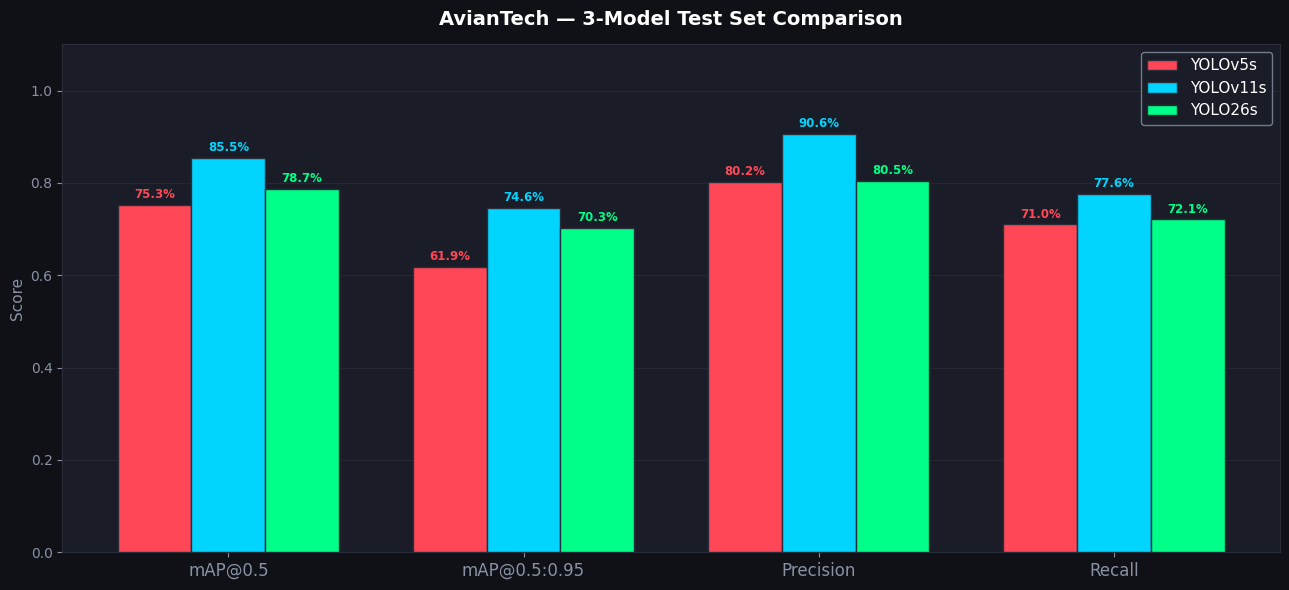

✅ Saved → C:\Users\Christian\AvianTech\results_charts_final\1_3model_grouped_bar.png


In [3]:
# ════════════════════════════════════════════════════════════════════════════
# CHART 1 — Grouped Bar Chart: Test Set Metrics
# ════════════════════════════════════════════════════════════════════════════
metric_labels = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall"]
v5_vals  = [0.753, 0.619, 0.802, 0.710]
v11_vals = [0.855, 0.746, 0.906, 0.776]
v26_vals = [0.787, 0.703, 0.805, 0.721]

x = np.arange(len(metric_labels))
w = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(CARD)
for sp in ax.spines.values(): sp.set_edgecolor("#2a2d3a")

bars1 = ax.bar(x - w,   v5_vals,  width=w, color=C5,  label="YOLOv5s",  edgecolor="#2a2d3a", zorder=3)
bars2 = ax.bar(x,       v11_vals, width=w, color=C11, label="YOLOv11s", edgecolor="#2a2d3a", zorder=3)
bars3 = ax.bar(x + w,   v26_vals, width=w, color=C26, label="YOLO26s",  edgecolor="#2a2d3a", zorder=3)

for bars, color in [(bars1, C5), (bars2, C11), (bars3, C26)]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{bar.get_height():.1%}", ha="center", va="bottom",
                fontsize=8.5, color=color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, color=WHT, fontsize=12)
ax.set_ylabel("Score", color=GRY, fontsize=11)
ax.set_ylim(0, 1.10)
ax.set_title("AvianTech — 3-Model Test Set Comparison",
             color=WHT, fontsize=14, fontweight="bold", pad=14)
ax.tick_params(colors=GRY)
ax.grid(axis="y", color="#2a2d3a", linewidth=0.5, zorder=0)
ax.legend(facecolor=CARD, edgecolor=GRY, labelcolor=WHT, fontsize=11)
plt.tight_layout()
save(fig, "1_3model_grouped_bar.png")


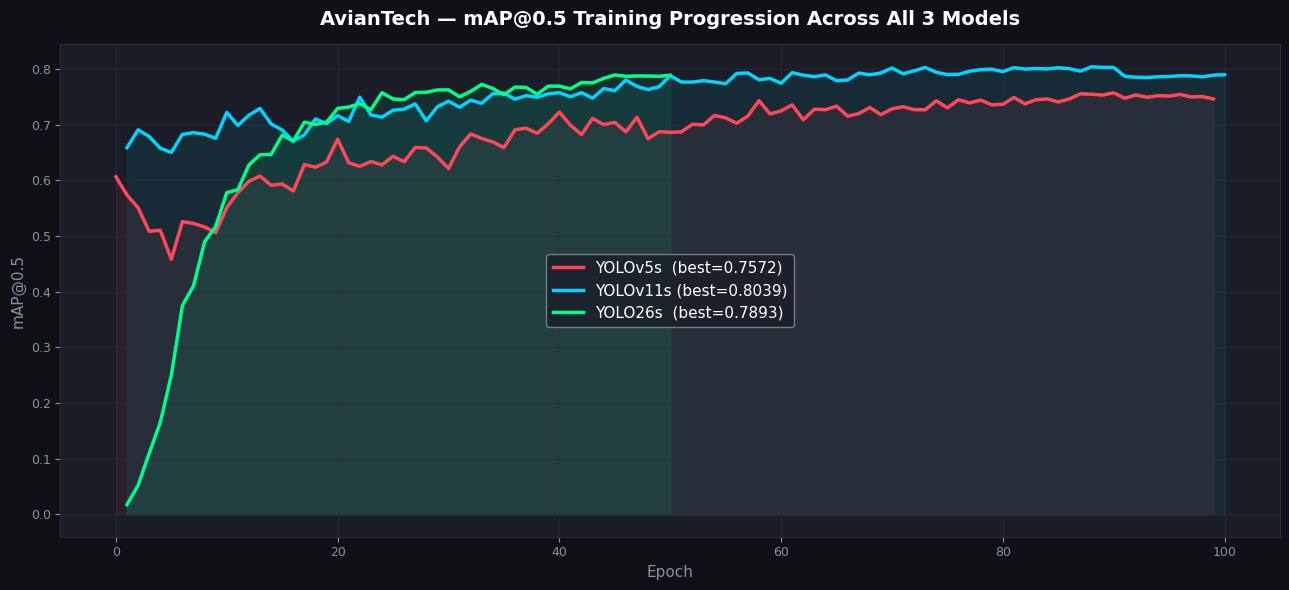

✅ Saved → C:\Users\Christian\AvianTech\results_charts_final\2_mAP_progression.png


In [4]:
# ════════════════════════════════════════════════════════════════════════════
# CHART 2 — mAP@0.5 Training Progression (all 3 models over epochs)
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(CARD)
for sp in ax.spines.values(): sp.set_edgecolor("#2a2d3a")

# YOLOv5 uses different column name
ax.plot(df5["epoch"],  df5["metrics/mAP_0.5"],   color=C5,  linewidth=2.5, label=f"YOLOv5s  (best={best5['metrics/mAP_0.5']:.4f})")
ax.plot(df11["epoch"], df11["metrics/mAP50(B)"],  color=C11, linewidth=2.5, label=f"YOLOv11s (best={best11['metrics/mAP50(B)']:.4f})")
ax.plot(df26["epoch"], df26["metrics/mAP50(B)"],  color=C26, linewidth=2.5, label=f"YOLO26s  (best={best26['metrics/mAP50(B)']:.4f})")

ax.fill_between(df5["epoch"],  df5["metrics/mAP_0.5"],  alpha=0.08, color=C5)
ax.fill_between(df11["epoch"], df11["metrics/mAP50(B)"], alpha=0.08, color=C11)
ax.fill_between(df26["epoch"], df26["metrics/mAP50(B)"], alpha=0.08, color=C26)

ax.set_xlabel("Epoch", color=GRY, fontsize=11)
ax.set_ylabel("mAP@0.5", color=GRY, fontsize=11)
ax.set_title("AvianTech — mAP@0.5 Training Progression Across All 3 Models",
             color=WHT, fontsize=14, fontweight="bold", pad=14)
ax.tick_params(colors=GRY, labelsize=9)
ax.grid(color="#2a2d3a", linewidth=0.5)
ax.legend(facecolor=CARD, edgecolor=GRY, labelcolor=WHT, fontsize=11)
plt.tight_layout()
save(fig, "2_mAP_progression.png")


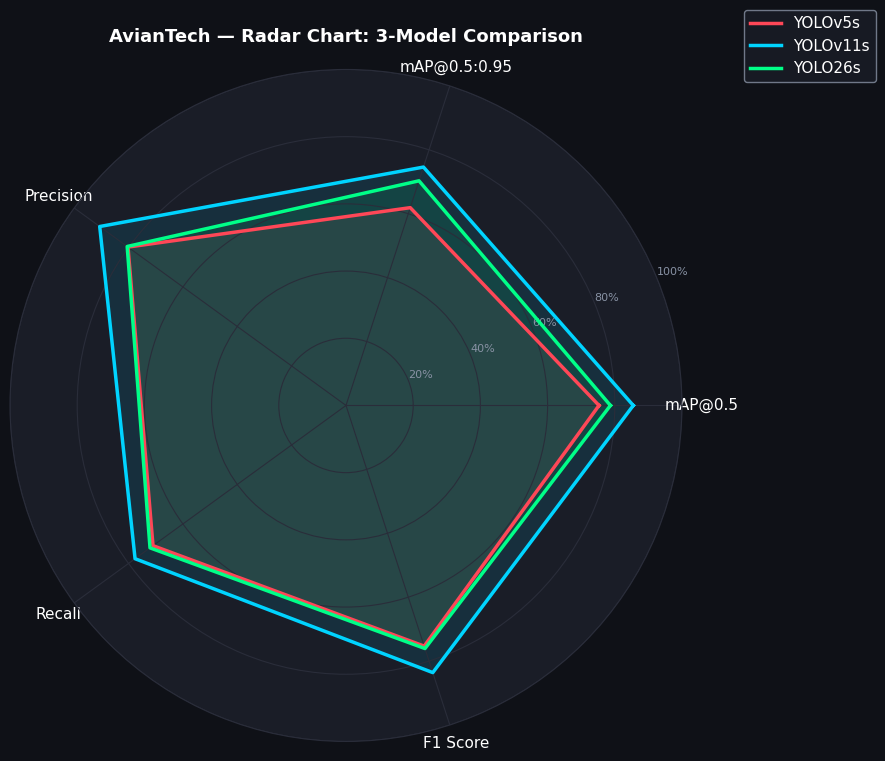

✅ Saved → C:\Users\Christian\AvianTech\results_charts_final\3_radar_3models.png


In [5]:
# ════════════════════════════════════════════════════════════════════════════
# CHART 3 — Radar Chart: 3 Models
# ════════════════════════════════════════════════════════════════════════════
from math import pi

radar_labels = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "F1 Score"]

# Compute F1
def f1(p, r): return 2*p*r/(p+r+1e-8)

v5_radar  = [0.753, 0.619, 0.802, 0.710, f1(0.802, 0.710)]
v11_radar = [0.855, 0.746, 0.906, 0.776, f1(0.906, 0.776)]
v26_radar = [0.787, 0.703, 0.805, 0.721, f1(0.805, 0.721)]

N = len(radar_labels)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

v5_r  = v5_radar  + v5_radar[:1]
v11_r = v11_radar + v11_radar[:1]
v26_r = v26_radar + v26_radar[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(BG); ax.set_facecolor(CARD)

ax.plot(angles, v5_r,  color=C5,  linewidth=2.5, label="YOLOv5s")
ax.fill(angles, v5_r,  color=C5,  alpha=0.10)
ax.plot(angles, v11_r, color=C11, linewidth=2.5, label="YOLOv11s")
ax.fill(angles, v11_r, color=C11, alpha=0.10)
ax.plot(angles, v26_r, color=C26, linewidth=2.5, label="YOLO26s")
ax.fill(angles, v26_r, color=C26, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, color=WHT, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["20%","40%","60%","80%","100%"], color=GRY, fontsize=8)
ax.grid(color="#2a2d3a", linewidth=0.8)
ax.spines["polar"].set_edgecolor("#2a2d3a")
ax.set_title("AvianTech — Radar Chart: 3-Model Comparison",
             color=WHT, fontsize=13, fontweight="bold", pad=20)
ax.legend(facecolor=CARD, edgecolor=GRY, labelcolor=WHT,
          fontsize=11, loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
save(fig, "3_radar_3models.png")


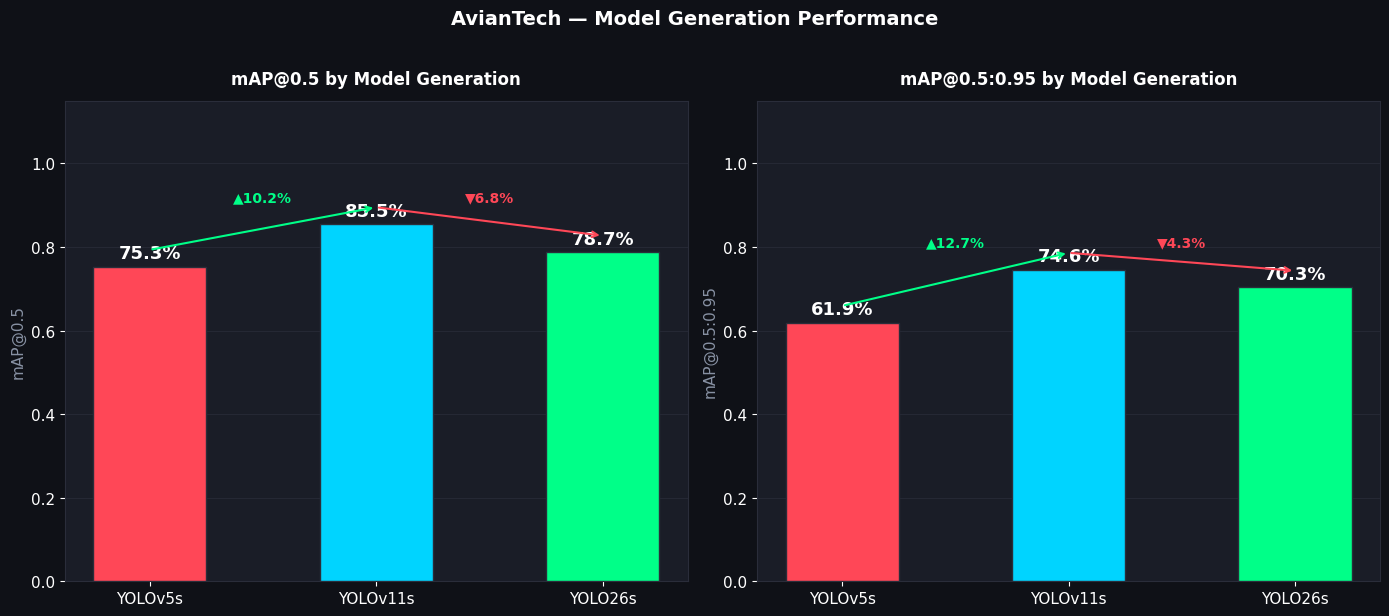

✅ Saved → C:\Users\Christian\AvianTech\results_charts_final\4_generation_improvement.png


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# CHART 4 — Generation Improvement Bar
# ════════════════════════════════════════════════════════════════════════════
models     = ["YOLOv5s", "YOLOv11s", "YOLO26s"]
map50_vals = [0.753, 0.855, 0.787]
map95_vals = [0.619, 0.746, 0.703]
colors_bar = [C5, C11, C26]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

for ax, vals, metric in [(ax1, map50_vals, "mAP@0.5"), (ax2, map95_vals, "mAP@0.5:0.95")]:
    ax.set_facecolor(CARD)
    for sp in ax.spines.values(): sp.set_edgecolor("#2a2d3a")
    bars = ax.bar(models, vals, color=colors_bar, edgecolor="#2a2d3a", width=0.5, zorder=3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.1%}", ha="center", va="bottom",
                fontsize=13, color=WHT, fontweight="bold")
    # Improvement arrows between bars
    for i in range(len(vals)-1):
        diff = vals[i+1] - vals[i]
        col  = GRN if diff > 0 else RED
        sym  = "▲" if diff > 0 else "▼"
        mid_x = i + 0.5
        ax.annotate("", xy=(i+1, vals[i+1]+0.04), xytext=(i, vals[i]+0.04),
                    arrowprops=dict(arrowstyle="->", color=col, lw=1.5))
        ax.text(mid_x, max(vals[i], vals[i+1]) + 0.055,
                f"{sym}{abs(diff)*100:.1f}%", ha="center",
                fontsize=10, color=col, fontweight="bold")
    ax.set_ylabel(metric, color=GRY, fontsize=11)
    ax.set_title(f"{metric} by Model Generation", color=WHT, fontsize=12, fontweight="bold", pad=12)
    ax.set_ylim(0, 1.15)
    ax.tick_params(colors=WHT, labelsize=11)
    ax.grid(axis="y", color="#2a2d3a", linewidth=0.5, zorder=0)

fig.suptitle("AvianTech — Model Generation Performance", color=WHT, fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save(fig, "4_generation_improvement.png")


Loading YOLOv11s per-class AP50...
Ultralytics 8.4.21  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO11s summary (fused): 101 layers, 9,427,119 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 620.9257.3 MB/s, size: 43.1 KB)
val: Scanning C:\Users\Christian\AvianTech\data\datasets\test\labels.cache... 185 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 185/185  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 4.3it/s 2.8s0.3s
                   all        185        290      0.906      0.775      0.855      0.746
Speed: 1.6ms preprocess, 9.0ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to C:\Users\Christian\AvianTech\runs\detect\val10
Loading YOLO26s per-class AP50...
Ultralytics 8.4.21  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO26s summary (fused): 122 layers, 9,47

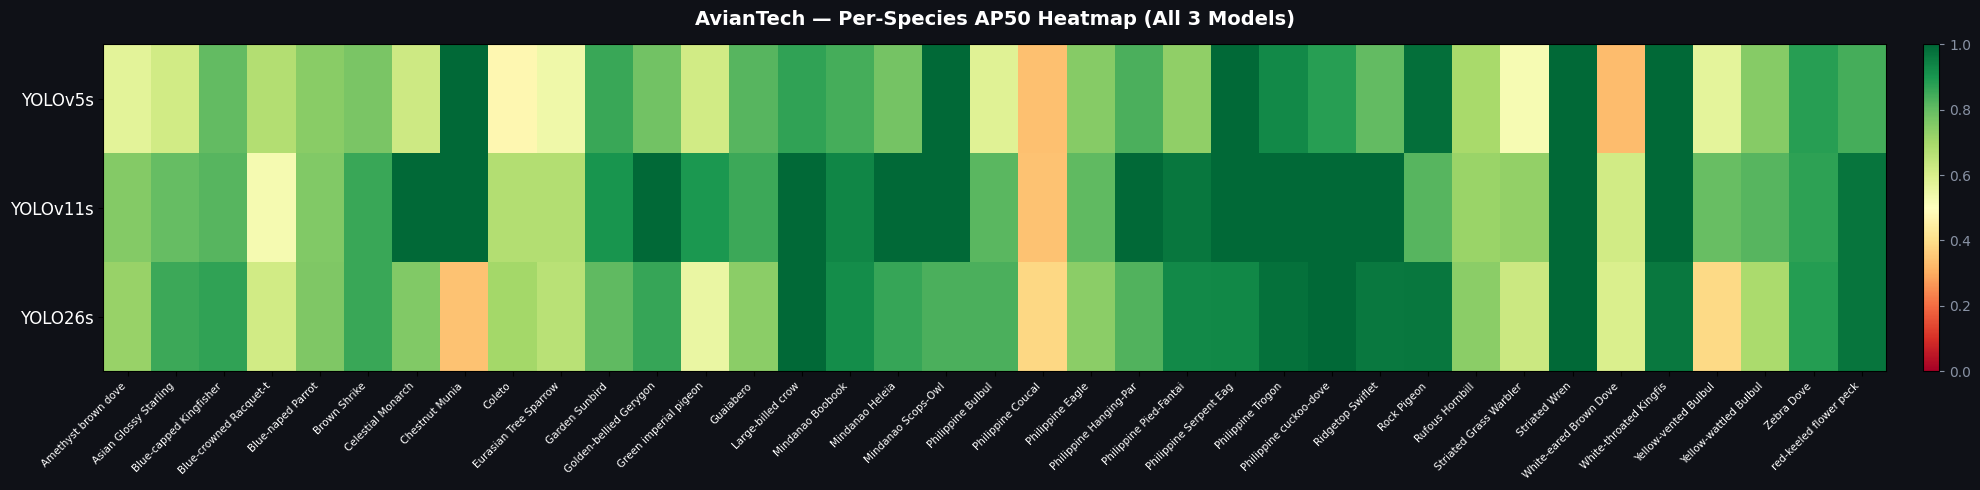

✅ Saved → C:\Users\Christian\AvianTech\results_charts_final\5_per_species_heatmap.png
✅ Per-class data loaded!


In [7]:
# ════════════════════════════════════════════════════════════════════════════
# CHART 5 — Per-Species AP50 Comparison Heatmap
# ════════════════════════════════════════════════════════════════════════════
from ultralytics import YOLO

# Load per-class AP50 for each model
def get_per_class_ap50(weights_path, yaml_path, split="test"):
    model = YOLO(weights_path)
    metrics = model.val(
        data=yaml_path, split=split, device=0, verbose=False)
    return list(model.names.values()), metrics.box.ap50

yaml_path = r"C:\Users\Christian\AvianTech\config\birds.yaml"

print("Loading YOLOv11s per-class AP50...")
names11, ap50_11 = get_per_class_ap50(
    r"C:\Users\Christian\AvianTech\models\yolov11\aviantech_v11_phase2\weights\best.pt", yaml_path)

print("Loading YOLO26s per-class AP50...")
names26, ap50_26 = get_per_class_ap50(
    r"C:\Users\Christian\AvianTech\models\yolo26\aviantech_v26_phase1\weights\best.pt", yaml_path)

# YOLOv5 per-class from test output
v5_per_class = {
    "Amethyst brown dove": 0.572, "Asian Glossy Starling": 0.617,
    "Blue-capped Kingfisher": 0.804, "Blue-crowned Racquet-tail": 0.672,
    "Blue-naped Parrot": 0.746, "Brown Shrike": 0.766,
    "Celestial Monarch": 0.622, "Chestnut Munia": 0.995,
    "Coleto": 0.476, "Eurasian Tree Sparrow": 0.540,
    "Garden Sunbird": 0.858, "Golden-bellied Gerygone": 0.779,
    "Green imperial pigeon": 0.615, "Guaiabero": 0.817,
    "Large-billed crow": 0.871, "Mindanao Boobook": 0.840,
    "Mindanao Heleia": 0.775, "Mindanao Scops-Owl": 0.995,
    "Philippine Bulbul": 0.582, "Philippine Coucal": 0.337,
    "Philippine Eagle": 0.749, "Philippine Hanging-Parrot": 0.835,
    "Philippine Pied-Fantail": 0.733, "Philippine Serpent Eagle": 0.995,
    "Philippine Trogon": 0.929, "Philippine cuckoo-dove": 0.879,
    "Ridgetop Swiflet": 0.803, "Rock Pigeon": 0.983,
    "Rufous Hornbill": 0.693, "Striated Grass Warbler": 0.521,
    "Striated Wren": 0.995, "White-eared Brown Dove": 0.332,
    "White-throated Kingfisher": 0.995, "Yellow-vented Bulbul": 0.567,
    "Yellow-wattled Bulbul": 0.748, "Zebra Dove": 0.880,
    "red-keeled flower pecker": 0.843,
}

ap50_5 = [v5_per_class.get(n, 0.0) for n in names26]

# Build heatmap data
heatmap_data = np.array([ap50_5, list(ap50_11), list(ap50_26)])
species_labels = [n[:22] for n in names26]

fig, ax = plt.subplots(figsize=(20, 5))
fig.patch.set_facecolor(BG); ax.set_facecolor(CARD)

im = ax.imshow(heatmap_data, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(species_labels)))
ax.set_xticklabels(species_labels, rotation=45, ha="right", fontsize=7.5, color=WHT)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["YOLOv5s", "YOLOv11s", "YOLO26s"], color=WHT, fontsize=12)
ax.set_title("AvianTech — Per-Species AP50 Heatmap (All 3 Models)",
             color=WHT, fontsize=14, fontweight="bold", pad=14)

cbar = plt.colorbar(im, ax=ax, orientation="vertical", fraction=0.02, pad=0.02)
cbar.ax.yaxis.set_tick_params(color=GRY)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=GRY)

plt.tight_layout()
save(fig, "5_per_species_heatmap.png")
print("✅ Per-class data loaded!")


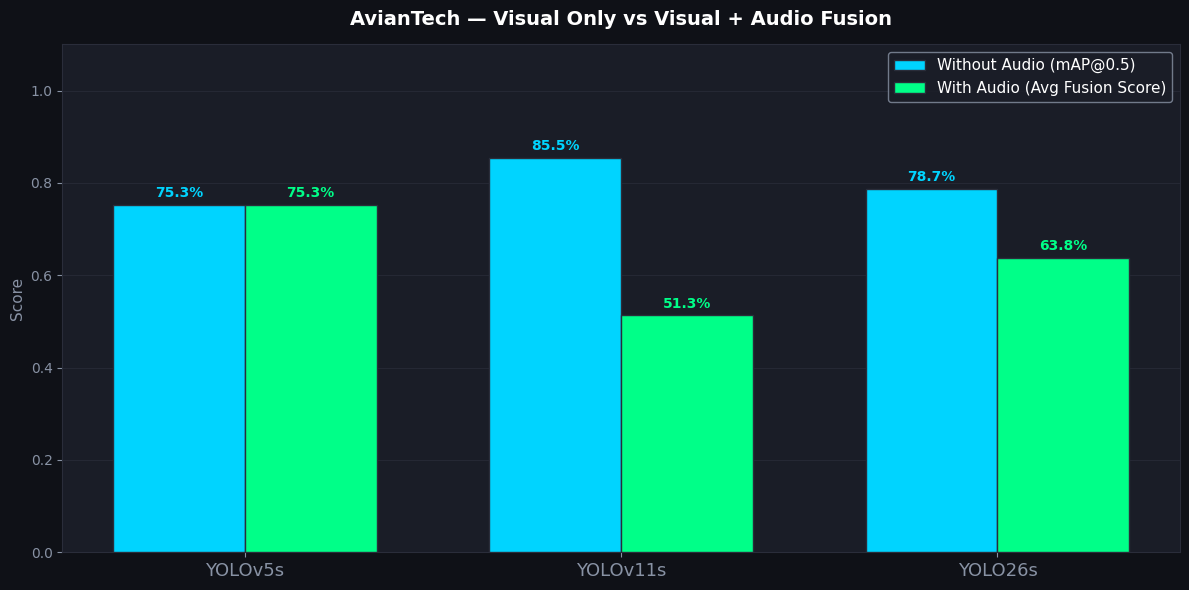

✅ Saved → C:\Users\Christian\AvianTech\results_charts_final\6_visual_vs_fusion.png


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# CHART 6 — With vs Without Audio: All 3 Models
# ════════════════════════════════════════════════════════════════════════════

# Load fusion results
df_v11_fusion = pd.read_excel(v11_xlsx, sheet_name="Fusion Results")
df_v26_fusion = pd.read_excel(v26_xlsx, sheet_name="Fusion Results")

# Fusion averages
v11_fusion_avg = df_v11_fusion["fusion_score"].mean()
v26_fusion_avg = df_v26_fusion["fusion_score"].mean()
v5_fusion_avg  = 0.0  # YOLOv5 did not have fusion in notebook

# Without audio (test set mAP50)
without_audio = [0.753, 0.855, 0.787]
# With audio (avg fusion score)
with_audio    = [v5_fusion_avg if v5_fusion_avg > 0 else 0.753,
                 v11_fusion_avg, v26_fusion_avg]

models = ["YOLOv5s", "YOLOv11s", "YOLO26s"]
x = np.arange(len(models))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(CARD)
for sp in ax.spines.values(): sp.set_edgecolor("#2a2d3a")

bars1 = ax.bar(x - w/2, without_audio, width=w, color=ACC,
               label="Without Audio (mAP@0.5)", edgecolor="#2a2d3a", zorder=3)
bars2 = ax.bar(x + w/2, with_audio,    width=w, color=GRN,
               label="With Audio (Avg Fusion Score)", edgecolor="#2a2d3a", zorder=3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.1%}", ha="center", va="bottom",
            fontsize=10, color=ACC, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.1%}", ha="center", va="bottom",
            fontsize=10, color=GRN, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(models, color=WHT, fontsize=13)
ax.set_ylabel("Score", color=GRY, fontsize=11)
ax.set_ylim(0, 1.10)
ax.set_title("AvianTech — Visual Only vs Visual + Audio Fusion",
             color=WHT, fontsize=14, fontweight="bold", pad=14)
ax.tick_params(colors=GRY)
ax.grid(axis="y", color="#2a2d3a", linewidth=0.5, zorder=0)
ax.legend(facecolor=CARD, edgecolor=GRY, labelcolor=WHT, fontsize=11)
plt.tight_layout()
save(fig, "6_visual_vs_fusion.png")


C:\Users\Christian\AppData\Local\Temp\ipykernel_3048\3882321641.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\Christian\AppData\Local\Temp\ipykernel_3048\3386703601.py:47: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=BG)
C:\Users\Christian\cv_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


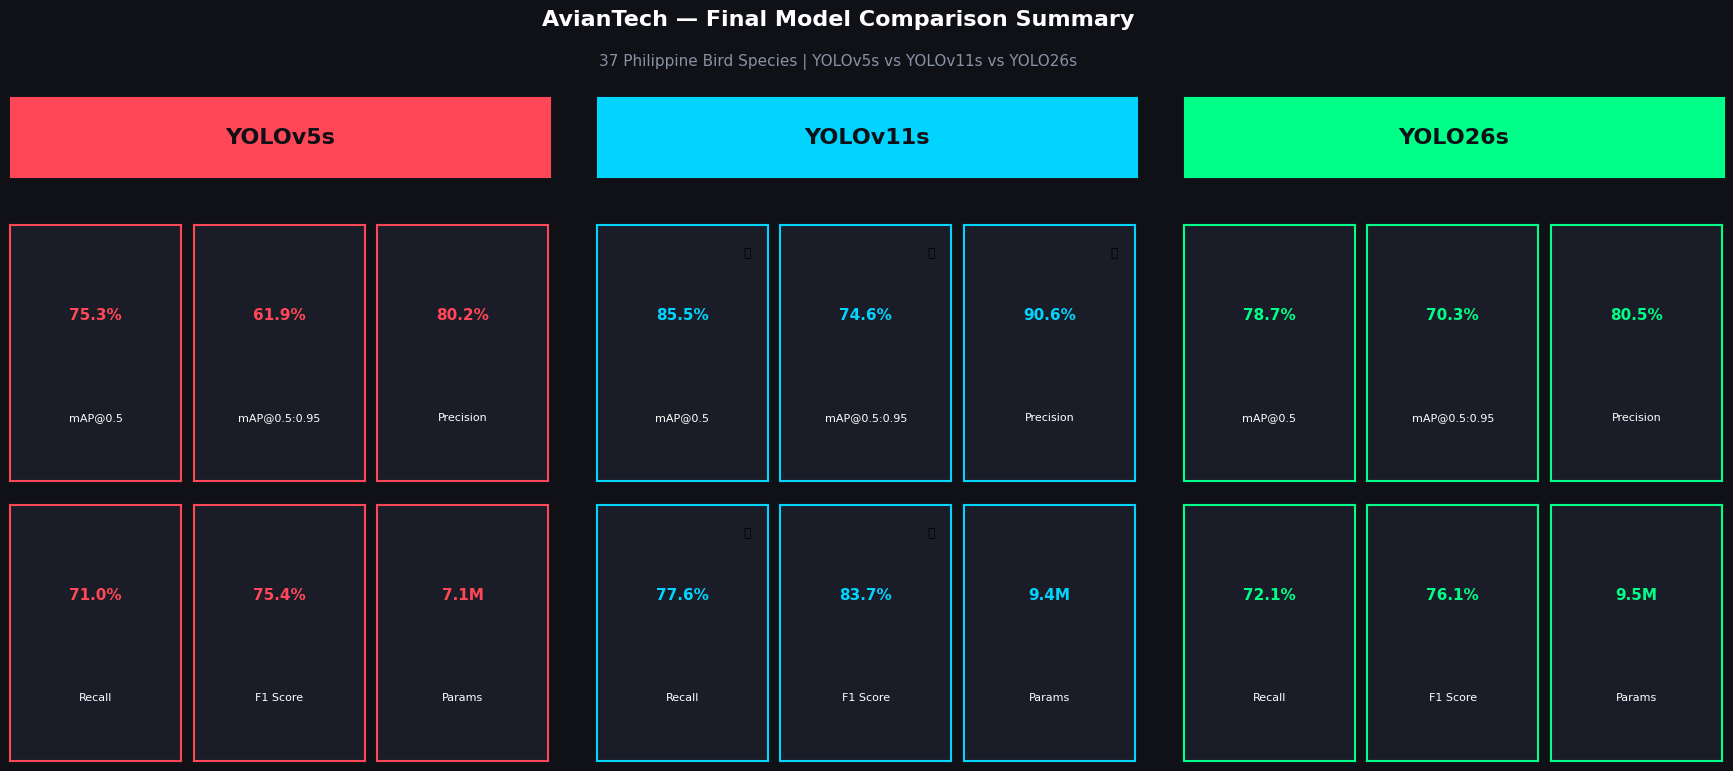

✅ Saved → C:\Users\Christian\AvianTech\results_charts_final\7_final_kpi_card.png


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# CHART 7 — Final KPI Summary Card (3 Models)
# ════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 8))
fig.patch.set_facecolor(BG)

fig.text(0.5, 0.97, "AvianTech — Final Model Comparison Summary",
         ha="center", fontsize=16, fontweight="bold", color=WHT)
fig.text(0.5, 0.92, "37 Philippine Bird Species | YOLOv5s vs YOLOv11s vs YOLO26s",
         ha="center", fontsize=11, color=GRY)

model_data = [
    ("YOLOv5s",  C5,  [("mAP@0.5","75.3%"), ("mAP@0.5:0.95","61.9%"),
                        ("Precision","80.2%"), ("Recall","71.0%"),
                        ("F1 Score","75.4%"), ("Params","7.1M")]),
    ("YOLOv11s", C11, [("mAP@0.5","85.5% ⭐"), ("mAP@0.5:0.95","74.6% ⭐"),
                        ("Precision","90.6% ⭐"), ("Recall","77.6% ⭐"),
                        ("F1 Score","83.7% ⭐"), ("Params","9.4M")]),
    ("YOLO26s",  C26, [("mAP@0.5","78.7%"), ("mAP@0.5:0.95","70.3%"),
                        ("Precision","80.5%"), ("Recall","72.1%"),
                        ("F1 Score","76.1%"), ("Params","9.5M")]),
]

for col_idx, (model_name, color, kpis) in enumerate(model_data):
    # Model header
    header_ax = fig.add_axes([0.04 + col_idx * 0.326, 0.78, 0.30, 0.10])
    header_ax.set_facecolor(color)
    for sp in header_ax.spines.values(): sp.set_edgecolor(color)
    header_ax.set_xticks([]); header_ax.set_yticks([])
    header_ax.text(0.5, 0.5, model_name, transform=header_ax.transAxes,
                   ha="center", va="center", fontsize=16, fontweight="bold", color=BG)

    # KPI cards
    for row_idx, (label, val) in enumerate(kpis):
        c = row_idx % 3
        r = row_idx // 3
        kpi_ax = fig.add_axes([0.04 + col_idx*0.326 + c*0.102, 0.38 - r*0.35 + 0.02, 0.095, 0.32])
        kpi_ax.set_facecolor(CARD)
        for sp in kpi_ax.spines.values(): sp.set_edgecolor(color); sp.set_linewidth(1.5)
        kpi_ax.set_xticks([]); kpi_ax.set_yticks([])
        kpi_ax.text(0.5, 0.65, val.replace(" ⭐",""), transform=kpi_ax.transAxes,
                    ha="center", va="center", fontsize=11, fontweight="bold", color=color)
        kpi_ax.text(0.5, 0.25, label, transform=kpi_ax.transAxes,
                    ha="center", va="center", fontsize=8, color=WHT)
        if "⭐" in val:
            kpi_ax.text(0.88, 0.88, "⭐", transform=kpi_ax.transAxes,
                        ha="center", fontsize=9)

plt.tight_layout()
save(fig, "7_final_kpi_card.png")


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY PRINTOUT
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("  AvianTech — Final 3-Model Comparison Summary")
print("  37 Philippine Bird Species | Test Set Results")
print("═"*65)
print(f"  {'Metric':<20} {'YOLOv5s':>12} {'YOLOv11s':>12} {'YOLO26s':>12}")
print("─"*65)

rows = [
    ("mAP@0.5",       0.753, 0.855, 0.787),
    ("mAP@0.5:0.95",  0.619, 0.746, 0.703),
    ("Precision",     0.802, 0.906, 0.805),
    ("Recall",        0.710, 0.776, 0.721),
    ("F1 Score",      f1(0.802,0.710), f1(0.906,0.776), f1(0.805,0.721)),
]

for label, v5, v11, v26 in rows:
    best = max(v5, v11, v26)
    def fmt(v): return f"{'⭐' if v==best else '  '}{v*100:.2f}%"
    print(f"  {label:<20} {fmt(v5):>12} {fmt(v11):>12} {fmt(v26):>12}")

print("─"*65)
print(f"  {'Parameters':<20} {'7.1M':>12} {'9.4M':>12} {'9.5M':>12}")
print(f"  {'Inference':<20} {'9.9ms':>12} {'~6ms':>12} {'11.8ms':>12}")
print("═"*65)

v11v5  = (0.855 - 0.753)*100
v26v11 = (0.787 - 0.855)*100
v26v5  = (0.787 - 0.753)*100

print(f"\n  📈 YOLOv5s → YOLOv11s : {v11v5:+.2f}% mAP@0.5")
print(f"  📈 YOLOv11s → YOLO26s : {v26v11:+.2f}% mAP@0.5")
print(f"  📈 YOLOv5s  → YOLO26s : {v26v5:+.2f}% mAP@0.5")
print(f"\n  🏆 Best overall model : YOLOv11s (mAP@0.5 = 85.5%)")
print(f"  ⚡ Most efficient     : YOLO26s (NMS-free, edge-ready)")
print(f"  📦 Lightest model     : YOLOv5s (7.1M params)")
print("═"*65)
print(f"\n🎉 All 7 charts saved to:\n   {save_dir}")



═════════════════════════════════════════════════════════════════
  AvianTech — Final 3-Model Comparison Summary
  37 Philippine Bird Species | Test Set Results
═════════════════════════════════════════════════════════════════
  Metric                    YOLOv5s     YOLOv11s      YOLO26s
─────────────────────────────────────────────────────────────────
  mAP@0.5                    75.30%      ⭐85.50%       78.70%
  mAP@0.5:0.95               61.90%      ⭐74.60%       70.30%
  Precision                  80.20%      ⭐90.60%       80.50%
  Recall                     71.00%      ⭐77.60%       72.10%
  F1 Score                   75.32%      ⭐83.60%       76.07%
─────────────────────────────────────────────────────────────────
  Parameters                   7.1M         9.4M         9.5M
  Inference                   9.9ms         ~6ms       11.8ms
═════════════════════════════════════════════════════════════════

  📈 YOLOv5s → YOLOv11s : +10.20% mAP@0.5
  📈 YOLOv11s → YOLO26s : -6.80% mAP@